# Estimate GHF from basal temperature posterior

In [1]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import src.model as model
import os
import scipy.io

data_path       = os.getenv('DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
split_data_path = "../data/train-validate-test/" # split data set
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
GHF_mean_filename    = 'trainingAll_GHF_sim_mean.mat'
GHF_std_filename     = 'trainingAll_GHF_sim_std.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
GHF_standardize_epsilon = preprocess_param['GHF_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("GHF_standardize_epsilon:", GHF_standardize_epsilon)

flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)
GHF_mean         = scipy.io.loadmat(folder + GHF_mean_filename)
GHF_std          = scipy.io.loadmat(folder + GHF_std_filename)

# load
Eb_standardized_train = np.load(split_data_path + XY_train_filename)['Eb_train']
Eb_standardized_valid = np.load(split_data_path + XY_valid_filename)['Eb_validation']
Eb_standardized_test  = np.load(split_data_path + XY_test_filename)['Eb_test']
GHF_standardized_train = np.load(split_data_path + XY_train_filename)['GHF_train']
GHF_standardized_valid = np.load(split_data_path + XY_valid_filename)['GHF_validation']
GHF_standardized_test  = np.load(split_data_path + XY_test_filename)['GHF_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()
GHF_mean = np.nan_to_num(GHF_mean['GHF_mean'], nan=0.0).flatten()
GHF_std  = np.nan_to_num(GHF_std['GHF_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of GHF_standardized_train:', GHF_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)


Eb_standardize_epsilon: 1287.4819202075
GHF_standardize_epsilon: 0.0181090261526068
Shape of Eb_standardized_train: (256, 256, 1, 833)
Shape of GHF_standardized_train: (256, 256, 1, 833)
Shape of domain mask: (256, 256)


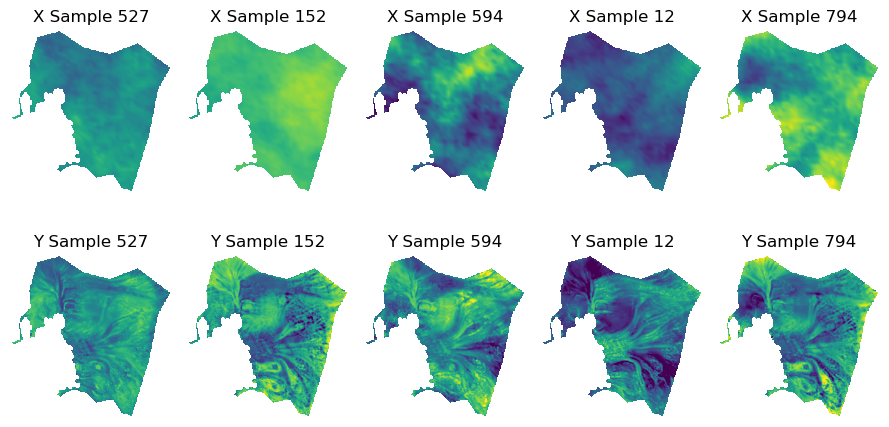

In [2]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
GHF_standardized_all = np.concatenate([GHF_standardized_train, 
                                       GHF_standardized_valid, 
                                       GHF_standardized_test], 
                                       axis=3)
md.load_sim_data(GHF_standardized_all, Eb_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 show_plot=True)

md.load_standardization_data(X_mean=GHF_mean, X_std=GHF_std,
                             Y_mean=Eb_mean, Y_std=Eb_std,
                             X_epsilon=GHF_standardize_epsilon, Y_epsilon=Eb_standardize_epsilon)

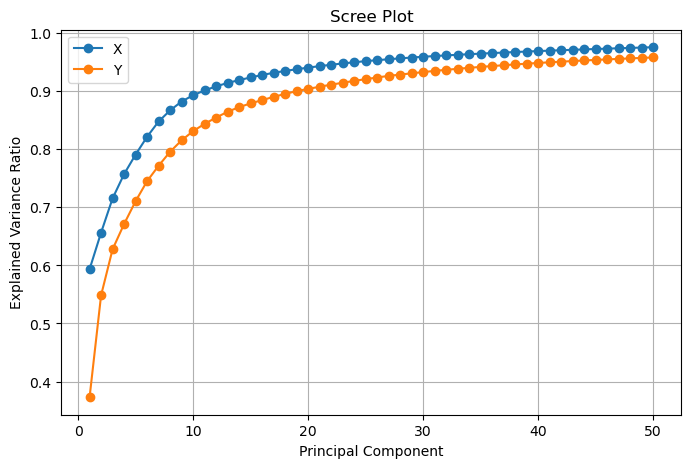

In [4]:
md.pca_scree(n_component_x=50, n_component_y=50)

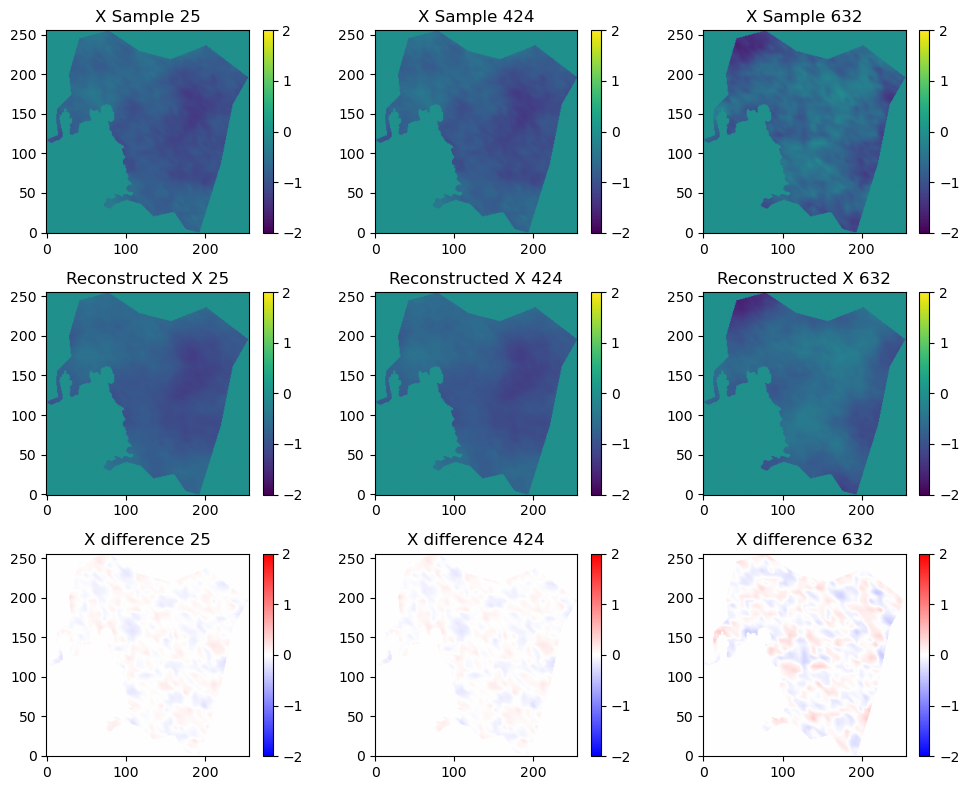

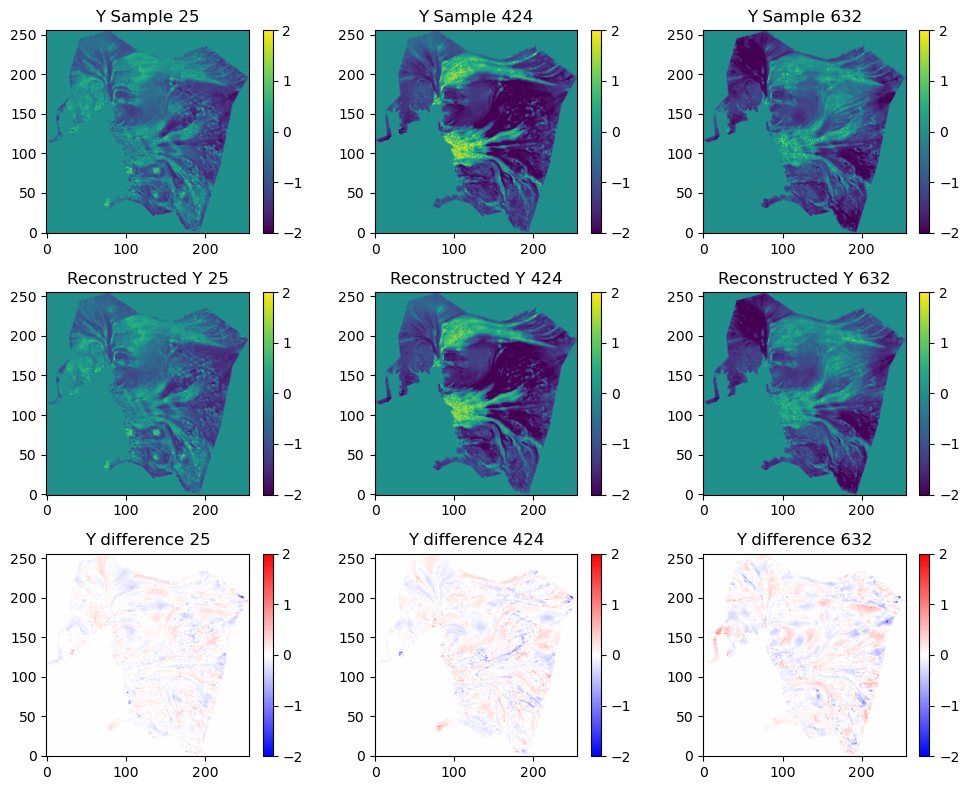

In [37]:
md.pca_recon_inspection(n_component_x=50, n_component_y=50)

In [3]:
from src.validation import bayesian_information_criterion

# reduce dim with PCA. 
# md.find_reduction_model_pca(n_component_x=20, n_component_y=20)
md.find_reduction_model_pls(n_pca_x=50, n_pca_y=50, n_pls=40)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PLS
md.load_split_data_pls(X_train=GHF_standardized_train, Y_train=Eb_standardized_train,
                       X_val=GHF_standardized_valid, Y_val=Eb_standardized_valid,
                       X_test=GHF_standardized_test, Y_test=Eb_standardized_test)

PCA-PLS joint space shape: (833, 80)


GMM training completed in 0.09 seconds.


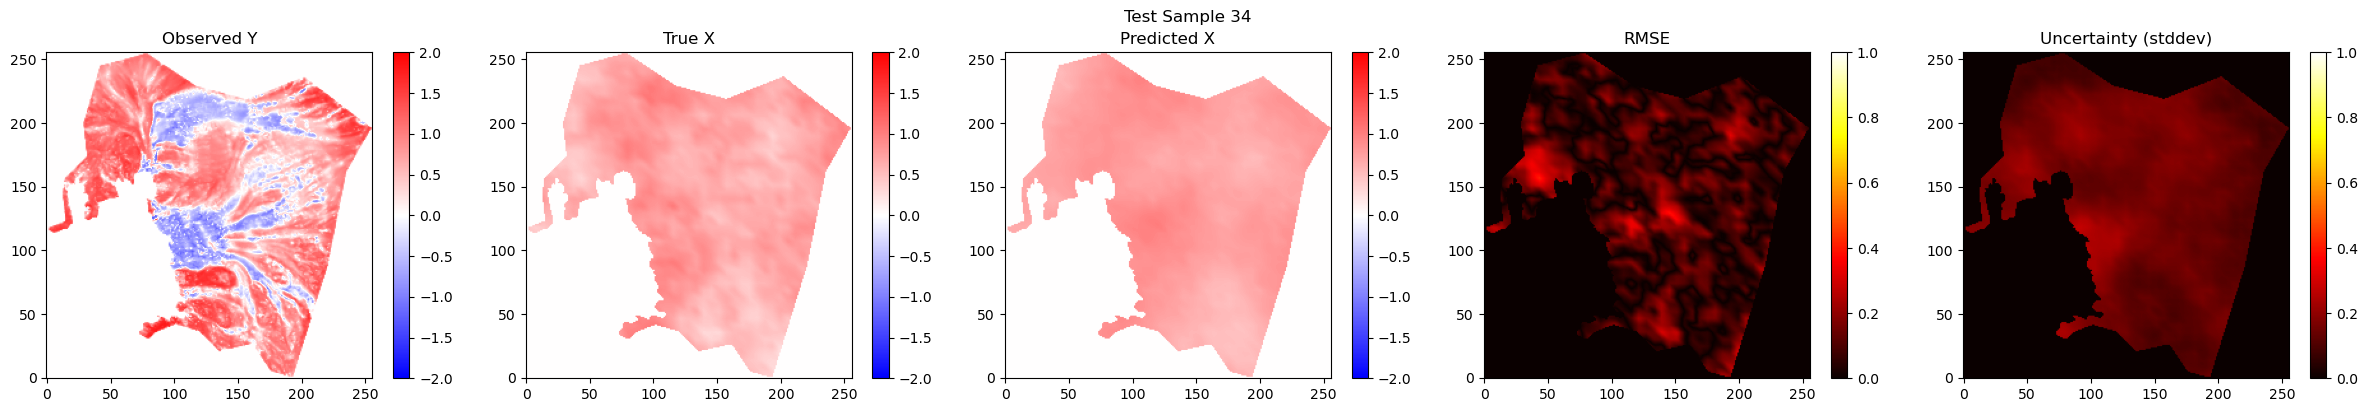

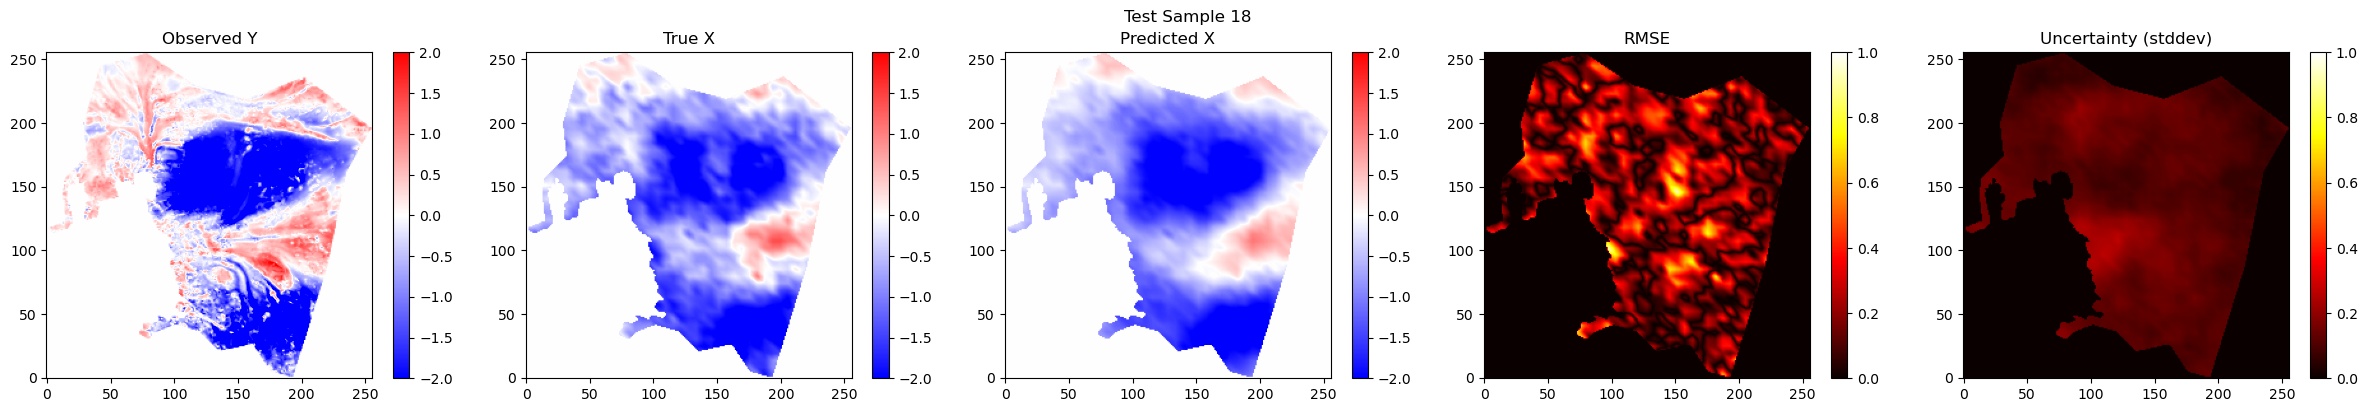

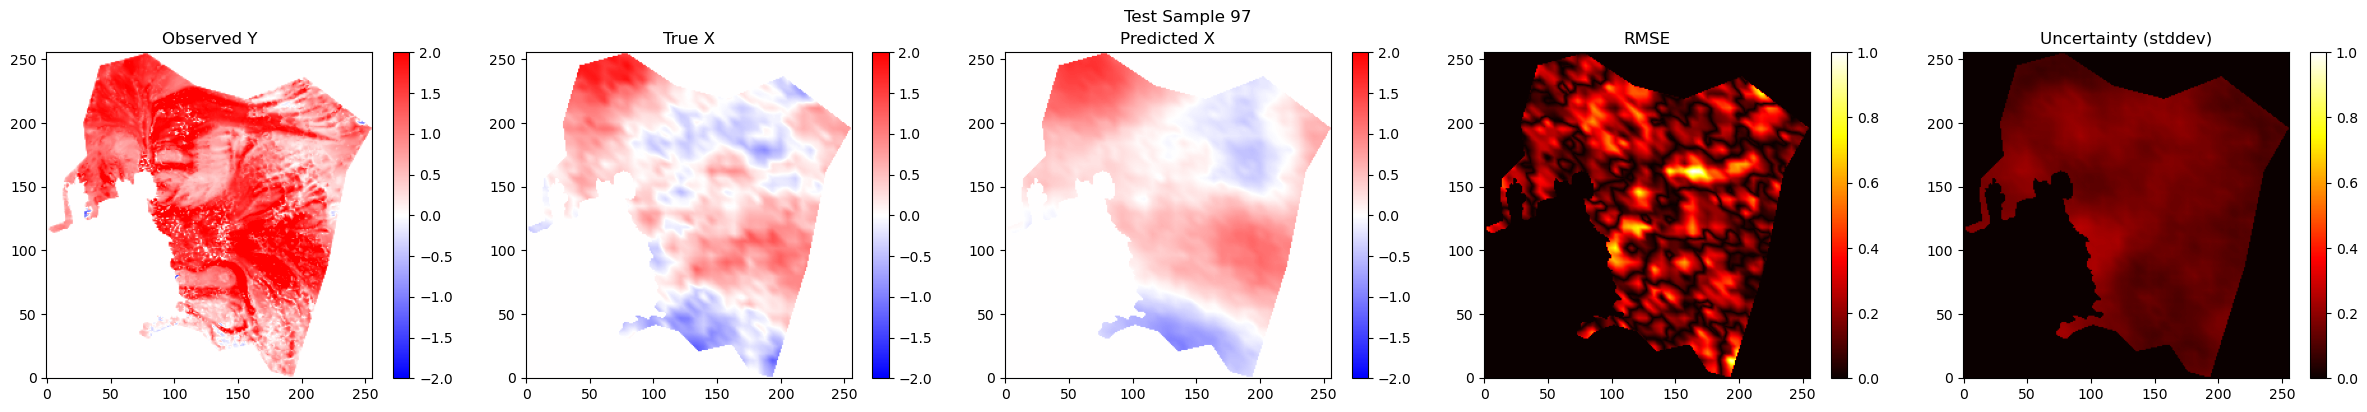

In [4]:
# based on the BIC sweep plot
n_optimal = 3
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples_pls(n_samples=3)

# Infer on posterior basal enthalpy

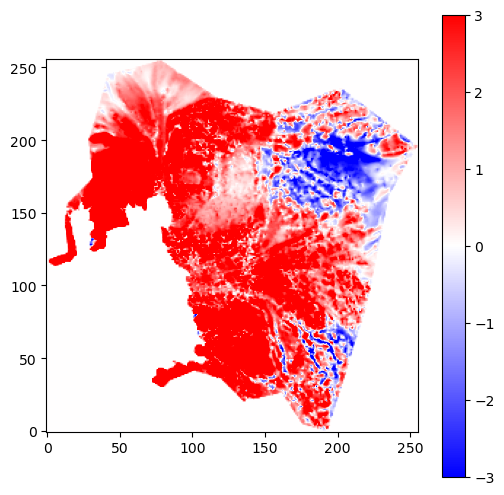

In [5]:
import torch

Eb_posterior_sample_path = "../data/posterior-hmc-samples/Eb_samples_norm_beta_1.npy"
Eb_posterior_samples = np.load(Eb_posterior_sample_path)

plt.figure(figsize=(6,6))
plt.imshow(np.mean(Eb_posterior_samples, axis=0).reshape(md.nx, md.ny), cmap='bwr', vmin=-3, vmax=3)
plt.gca().invert_yaxis()
plt.colorbar()
plt.show()

In [6]:
# use each sample as a condition on md.gmm
n_uq_sample = 30
GHF_conditioned_samples = []
for i, sample in enumerate(Eb_posterior_samples):

    y_latent = md.pca_x.transform(sample.reshape(1, -1)) @ md.pls.x_loadings_ 
    condition_index = np.arange(md.ndim_reduced_y)
    x_pred_gmm = md.gmm.condition(condition_index, y_latent)

    x_uq_samples = x_pred_gmm.sample(n_uq_sample)   # shape (400, 12)
    GHF_conditioned_samples.append(x_uq_samples)

    if i%50==0:
        print(f"Processed {i} samples")


Processed 0 samples
Processed 50 samples
Processed 100 samples
Processed 150 samples
Processed 200 samples
Processed 250 samples
Processed 300 samples
Processed 350 samples
Processed 400 samples
Processed 450 samples
Processed 500 samples
Processed 550 samples
Processed 600 samples
Processed 650 samples
Processed 700 samples
Processed 750 samples
Processed 800 samples
Processed 850 samples
Processed 900 samples
Processed 950 samples
Processed 1000 samples
Processed 1050 samples
Processed 1100 samples
Processed 1150 samples
Processed 1200 samples
Processed 1250 samples
Processed 1300 samples
Processed 1350 samples
Processed 1400 samples
Processed 1450 samples
Processed 1500 samples
Processed 1550 samples
Processed 1600 samples
Processed 1650 samples
Processed 1700 samples
Processed 1750 samples
Processed 1800 samples
Processed 1850 samples
Processed 1900 samples
Processed 1950 samples
Processed 2000 samples
Processed 2050 samples
Processed 2100 samples
Processed 2150 samples
Processed 2

In [13]:
from src.utilities import reverse_standardize

GHF_conditioned_samples = np.vstack(GHF_conditioned_samples) # shape (n_samples, n_uq_sample, n_features)   
print("Shape of GHF_conditioned_samples:", GHF_conditioned_samples.shape)


N = GHF_conditioned_samples.shape[0]
n_pixels = md.nx * md.ny  # 65536
chunk_size = 1000  # process 1000 samples at a time → ~500MB peak

# Welford's online algorithm for mean + variance (no storage of all samples)
# For percentiles we need a different approach — reservoir or chunked sort
# Strategy: store only what's needed per pixel

# --- Mean and Std via Welford (O(n_pixels) memory) ---
running_mean = np.zeros(n_pixels)
running_M2   = np.zeros(n_pixels)  # sum of squared deviations

for start in range(0, N, chunk_size):
    end = min(start + chunk_size, N)
    chunk = GHF_conditioned_samples[start:end]          # (chunk, 40)
    
    chunk_pca   = chunk @ md.pls.x_loadings_.T          # (chunk, 50)
    chunk_pixel = md.pca_x.inverse_transform(chunk_pca) # (chunk, n_pixels)
    
    # reverse standardization
    chunk_pixel = reverse_standardize(chunk_pixel, 
                                      md.X_mean, 
                                      md.X_std, 
                                      method='relaxation', 
                                      epsilon=GHF_standardize_epsilon)
    
    # Welford update
    for i in range(len(chunk_pixel)):
        n_seen = start + i + 1
        delta  = chunk_pixel[i] - running_mean
        running_mean += delta / n_seen
        delta2 = chunk_pixel[i] - running_mean
        running_M2   += delta * delta2

    if start % (10*chunk_size) == 0:
        print(f"Processed {start} / {N} samples for mean/std")

GHF_mean = running_mean.reshape(md.nx, md.ny)
GHF_std  = np.sqrt(running_M2 / N).reshape(md.nx, md.ny)

# --- Percentiles via reservoir: store sorted values per pixel ---
# This is the hard part. Two practical options:

# OPTION A: Subsample (fast, approximate)
# If N=120000, taking 5000 random samples gives very accurate percentiles
rng = np.random.default_rng(42)
idx_sub = rng.choice(N, size=5000, replace=False)
sub_pca   = GHF_conditioned_samples[idx_sub] @ md.pls.x_loadings_.T
sub_pixel = md.pca_x.inverse_transform(sub_pca)
sub_pixel = reverse_standardize(sub_pixel, 
                                md.X_mean, 
                                md.X_std, 
                                method='relaxation', 
                                epsilon=GHF_standardize_epsilon)
# shape: (5000, n_pixels) → ~2.6 GB, borderline — reduce to 2000 if needed

GHF_p05 = np.percentile(sub_pixel,  5, axis=0).reshape(md.nx, md.ny)
GHF_p95 = np.percentile(sub_pixel, 95, axis=0).reshape(md.nx, md.ny)
del sub_pixel  # free immediately


Shape of GHF_conditioned_samples: (120000, 40)
Processed 0 / 120000 samples for mean/std
Processed 10000 / 120000 samples for mean/std
Processed 20000 / 120000 samples for mean/std
Processed 30000 / 120000 samples for mean/std
Processed 40000 / 120000 samples for mean/std
Processed 50000 / 120000 samples for mean/std
Processed 60000 / 120000 samples for mean/std
Processed 70000 / 120000 samples for mean/std
Processed 80000 / 120000 samples for mean/std
Processed 90000 / 120000 samples for mean/std
Processed 100000 / 120000 samples for mean/std
Processed 110000 / 120000 samples for mean/std


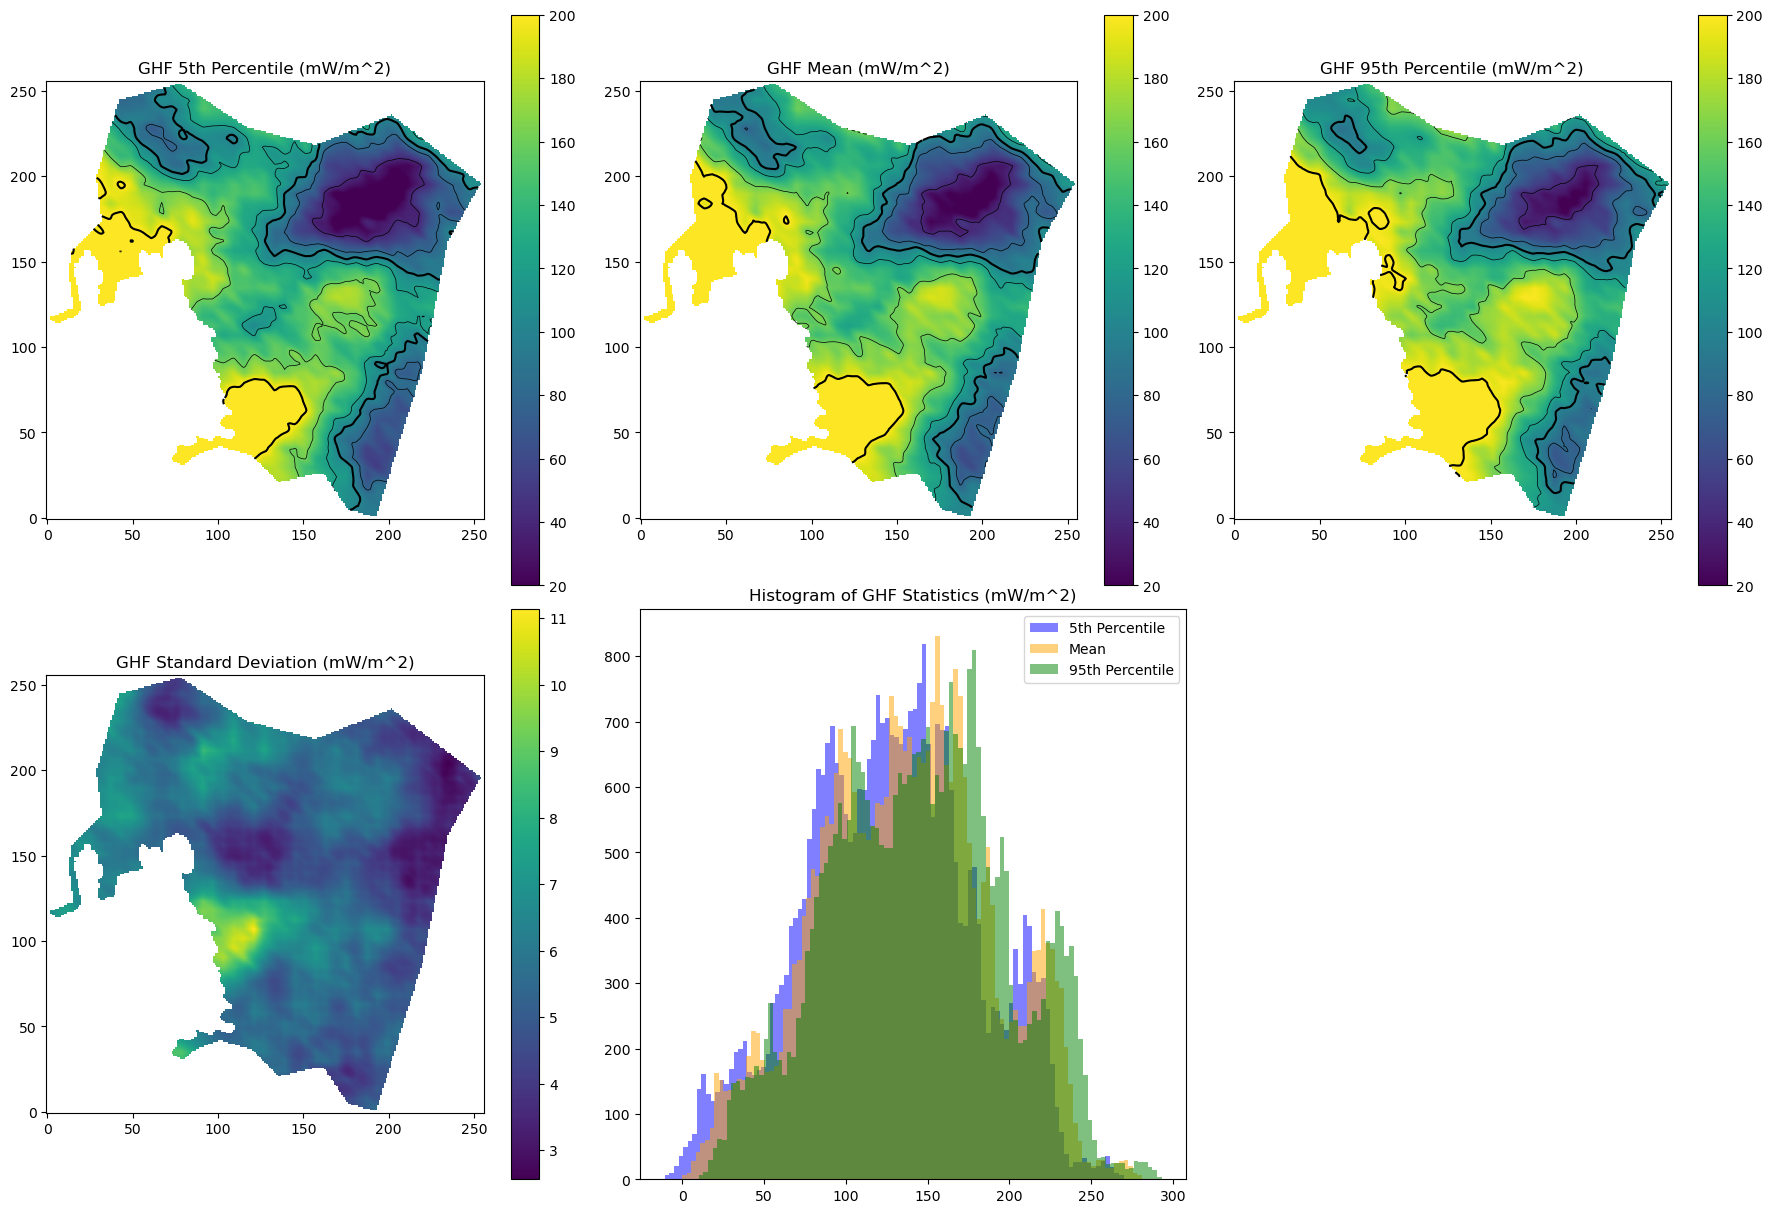

In [44]:
# make plots
contour_levels = [40, 80, 120, 160, 200]
contour_bold_levels = [100, 200]
GHF_p05[~model_bound_data_ori] = np.nan
GHF_mean[~model_bound_data_ori] = np.nan
GHF_p95[~model_bound_data_ori] = np.nan
GHF_std[~model_bound_data_ori] = np.nan
plt.figure(figsize=(18,12))
plt.subplot(2,3,1)
plt.imshow(GHF_p05 * 1e3, cmap='viridis', vmin=20, vmax=200)
plt.colorbar()
plt.contour(GHF_p05 * 1e3, levels=contour_levels, colors='black', linewidths=0.5)
plt.contour(GHF_p05 * 1e3, levels=contour_bold_levels, colors='black', linewidths=1.5)
plt.title('GHF 5th Percentile (mW/m^2)')
plt.gca().invert_yaxis()
plt.subplot(2,3,2)
plt.imshow(GHF_mean * 1e3, cmap='viridis', vmin=20, vmax=200)
plt.colorbar()
plt.contour(GHF_mean * 1e3, levels=contour_levels, colors='black', linewidths=0.5)
plt.contour(GHF_mean * 1e3, levels=contour_bold_levels, colors='black', linewidths=1.5)
plt.title('GHF Mean (mW/m^2)')
plt.gca().invert_yaxis()
plt.subplot(2,3,3)
plt.imshow(GHF_p95 * 1e3, cmap='viridis', vmin=20, vmax=200)
plt.colorbar()
plt.contour(GHF_p95 * 1e3, levels=contour_levels, colors='black', linewidths=0.5)
plt.contour(GHF_p95 * 1e3, levels=contour_bold_levels, colors='black', linewidths=1.5)
plt.title('GHF 95th Percentile (mW/m^2)')
plt.gca().invert_yaxis()
plt.subplot(2,3,4)
plt.imshow(GHF_std * 1e3, cmap='viridis')
plt.title('GHF Standard Deviation (mW/m^2)')
plt.gca().invert_yaxis()
plt.colorbar()
plt.tight_layout()
plt.subplot(2,3,5)
plt.hist(GHF_p05[model_bound_data_ori].flatten() * 1e3, bins=100, color='blue', alpha=0.5)
plt.hist(GHF_mean[model_bound_data_ori].flatten() * 1e3, bins=100, color='orange', alpha=0.5)
plt.hist(GHF_p95[model_bound_data_ori].flatten() * 1e3, bins=100, color='green', alpha=0.5)
plt.legend(['5th Percentile', 'Mean', '95th Percentile'])
plt.title('Histogram of GHF Statistics (mW/m^2)')
plt.show()